# rejectkit on real data — Home Credit Default Risk
## 실데이터 적용 / 実データ適用

**[한국어]** 합성데이터가 아니라 **실제 공개 데이터**(Kaggle Home Credit Default Risk, 30만 건, 부도율 8%)에 `rejectkit`을 적용한다. 핵심 질문: *현실 데이터에서 reject inference가 정말 도움이 되나?*

**[English]** Applies `rejectkit` to a **real public dataset** (Kaggle Home Credit Default Risk, 307k rows, ~8% bad). The question: *does reject inference actually help on real data?*

**[日本語]** 合成ではなく**実際の公開データ**（Kaggle Home Credit Default Risk、30万件、延滞率約8%）に `rejectkit` を適用する。問いは「実データで reject inference は本当に役立つか？」。

> Data: https://www.kaggle.com/c/home-credit-default-risk (`application_train.csv`). Set `HC_CSV` or edit the path below.

In [1]:
import os, sys, pathlib, warnings
warnings.filterwarnings('ignore')
try:
    import rejectkit  # noqa
except ImportError:
    for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_p / 'src' / 'rejectkit').exists():
            sys.path.insert(0, str(_p / 'src')); break
%matplotlib inline
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import rejectkit as rk
from rejectkit import MaskedRejectBenchmark, RejectInferenceClassifier, plotting
from rejectkit.diagnostics import feature_drift, auc
pd.set_option('display.width', 130)
print('rejectkit', rk.__version__)

rejectkit 0.3.0


## 1. Load & preprocess / 로드·전처리 / 読み込み・前処理

**[한국어]** 강한 예측변수(EXT_SOURCE 1–3, 대출·소득 금액, 나이·근속일수 등) + 범주형 3개를 선택, 이상치(DAYS_EMPLOYED=365243)를 결측 처리, 원핫인코딩·중앙값 대치·표준화 후 3만 건을 층화 추출한다. `1=부도(bad)`.

**[English]** Select strong predictors (EXT_SOURCE 1–3, loan/income amounts, age, employment days) + 3 categoricals, fix the DAYS_EMPLOYED=365243 anomaly, one-hot + median-impute + standardize, then take a stratified 30k sample. `1 = bad`.

**[日本語]** 強い予測変数（EXT_SOURCE 1–3、融資・所得額、年齢・勤続日数）＋カテゴリ3列を選び、異常値(DAYS_EMPLOYED=365243)を欠損化し、one-hot・中央値補完・標準化のうえ3万件を層化抽出する。`1=延滞(bad)`。

In [2]:
CANDIDATES = [r'C:\\claude\\ds\\pj6\\data\\hc\\application_train.csv',
              'application_train.csv',
              os.path.join('data', 'hc', 'application_train.csv'),
              os.environ.get('HC_CSV', '')]
HC_CSV = next((p for p in CANDIDATES if p and os.path.exists(p)), None)
assert HC_CSV, 'Set HC_CSV to your Home Credit application_train.csv path.'

num = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
       'AMT_INCOME_TOTAL','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_ID_PUBLISH','REGION_POPULATION_RELATIVE','CNT_CHILDREN']
cat = ['NAME_EDUCATION_TYPE','NAME_INCOME_TYPE','CODE_GENDER']
df = pd.read_csv(HC_CSV, usecols=['TARGET'] + num + cat)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df = df.groupby('TARGET', group_keys=False).sample(frac=30000/len(df), random_state=0)
y = df['TARGET'].to_numpy().astype(int)
Xc = pd.get_dummies(df[cat], drop_first=True)
Xn = df[num].fillna(df[num].median())
X = pd.concat([Xn.reset_index(drop=True), Xc.reset_index(drop=True)], axis=1)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
print('design matrix:', X.shape, '| bad rate:', round(float(y.mean()), 4))
display(X.head(3).round(3))

design matrix: (30000, 23) | bad rate: 0.0807


,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,...,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,CODE_GENDER_M
0,0.010,1.065,0.868,-0.065,0.152,-0.120,0.712,-1.343,0.280,-1.490,...,-0.184,-0.111,0.641,-0.545,2.113,-0.276,-0.012,-0.012,-1.034,-0.717
1,-2.911,1.328,0.594,-0.933,-1.180,-0.851,-0.555,1.243,0.955,0.074,...,-0.184,-0.111,-1.560,1.835,-0.473,-0.276,-0.012,-0.012,-1.034,1.396
2,0.128,-0.799,0.904,0.288,1.438,0.368,0.078,-0.330,-2.056,1.277,...,-0.184,-0.111,0.641,-0.545,-0.473,3.621,-0.012,-0.012,-1.034,-0.717


## 2. Does reject inference help? (headline) / 핵심 / 核心

**[한국어]** `MaskedRejectBenchmark`로 **MNAR**(승인이 숨은 결과에 의존하는 현실적 케이스)에서 검증한다. `auc_recovery`: 0=naive(승인자만)와 동급, 1=oracle(전체) 회복.

**[English]** Validate under **MNAR** (acceptance depends on the hidden outcome — the realistic case). `auc_recovery`: 0 = tied with naive (accepts-only), 1 = recovers the oracle (full data).

**[日本語]** **MNAR**（承認が隠れた結果に依存する現実的ケース）で `MaskedRejectBenchmark` により検証する。`auc_recovery`：0=naive（承認者のみ）と同等、1=oracle（全データ）回復。

In [3]:
methods = ['simple','fuzzy','parcelling','reweighting','extrapolation','selflearning','heckman']
bench = MaskedRejectBenchmark(selection='mnar', accept_rate=0.6, selection_strength=2.0, random_state=0)
mnar = bench.compare(methods, X, y)
print('accepts=%d  rejects=%d  test=%d' % (mnar.attrs['n_accept'], mnar.attrs['n_reject'], mnar.attrs['n_test']))
display(mnar.round(4))

accepts=12600  rejects=8400  test=9000


,auc,ks,gini,auc_recovery
oracle,0.7413,0.3663,0.4826,1.0000
naive,0.5680,0.1145,0.1359,0.0000
simple,0.5751,0.1215,0.1503,0.0415
fuzzy,0.5733,0.1192,0.1466,0.0308
parcelling,0.5824,0.1403,0.1649,0.0836
reweighting,0.5751,0.1213,0.1501,0.0410
extrapolation,0.5817,0.1296,0.1634,0.0792
selflearning,0.5751,0.1215,0.1503,0.0415
heckman,0.5803,0.1378,0.1606,0.0712


**[한국어]** 실데이터에서 naive AUC가 oracle 대비 크게 무너지고(선택편향), **여러 RI 기법이 그 손실의 7–8%를 실제로 회복**한다 — 합성데이터와 달리 여기선 reject inference가 도움이 된다.

**[English]** On real data, naive AUC collapses far below the oracle (selection bias), and **several RI methods genuinely recover 7–8% of the lost gap** — unlike the synthetic case, here reject inference helps.

**[日本語]** 実データでは naive の AUC が oracle より大きく低下し（選択バイアス）、**複数の RI 手法が損失の7–8%を実際に回復**する。合成データと違い、ここでは reject inference が役立つ。

### Other selection regimes / 다른 선택 메커니즘 / 他の選択機構
**[한국어]** MAR·cutoff에선 naive가 이미 oracle급이라 회복할 게 없어 `auc_recovery`가 NaN — RI가 불필요한 경우. (selflearning이 cutoff에서 붕괴하는 것도 보인다: 항상 벤치마크하라는 교훈.)

**[English]** Under MAR/cutoff the naive model already matches the oracle (nothing to recover → `auc_recovery` is NaN) — RI is unnecessary. (Note selflearning collapsing under cutoff: always benchmark.)

**[日本語]** MAR・cutoff では naive が既に oracle 並みで回復の余地が無く `auc_recovery` は NaN — RI 不要のケース。（cutoff で selflearning が崩れる点にも注意：必ずベンチマークを。）

In [4]:
for sel in ['mar', 'cutoff']:
    r = MaskedRejectBenchmark(selection=sel, accept_rate=0.6, selection_strength=2.0, random_state=0).compare(methods, X, y)
    print(f'--- {sel} ---')
    display(r.round(4)[['auc','ks','gini','auc_recovery']])

--- mar ---


,auc,ks,gini,auc_recovery
oracle,0.7413,0.3663,0.4826,NaN
naive,0.7376,0.3553,0.4752,NaN
simple,0.7046,0.3283,0.4093,NaN
fuzzy,0.7376,0.3541,0.4753,NaN
parcelling,0.7383,0.3528,0.4765,NaN
reweighting,0.7353,0.3484,0.4705,NaN
extrapolation,0.7397,0.3676,0.4793,NaN
selflearning,0.6886,0.3054,0.3771,NaN
heckman,0.7398,0.3571,0.4797,NaN


--- cutoff ---


,auc,ks,gini,auc_recovery
oracle,0.7413,0.3663,0.4826,NaN
naive,0.7410,0.3639,0.4819,NaN
simple,0.6541,0.2283,0.3083,NaN
fuzzy,0.7409,0.3631,0.4818,NaN
parcelling,0.7400,0.3691,0.4801,NaN
reweighting,0.7401,0.3640,0.4801,NaN
extrapolation,0.6987,0.3011,0.3975,NaN
selflearning,0.2965,0.0002,-0.4071,NaN
heckman,0.7408,0.3674,0.4816,NaN


## 3. Single-model workflow + drift / 단일 모델 + 드리프트 / 単一モデル＋ドリフト

**[한국어]** MNAR 방식으로 승인/거절을 모의한 뒤, naive와 `RejectInferenceClassifier`(parcelling)를 학습해 홀드아웃 전체 모집단에서 AUC를 비교하고, 승인 vs 거절의 변수 드리프트(PSI)를 본다.

**[English]** Simulate MNAR acceptance, then train naive vs `RejectInferenceClassifier` (parcelling), compare AUC on the held-out full population, and inspect accept-vs-reject feature drift (PSI).

**[日本語]** MNAR 方式で承認/否認を模擬し、naive と `RejectInferenceClassifier`(parcelling) を学習して ホールドアウト全集団で AUC を比較、承認 vs 否認の特徴量ドリフト(PSI)を見る。

In [5]:
rng = np.random.default_rng(0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
feat = Xtr.to_numpy() @ rng.normal(size=X.shape[1]); feat = feat / (feat.std() + 1e-9)
z = feat + 2.0 * (0.5 - ytr) * 2 + rng.normal(size=len(ytr))   # MNAR: goods more likely accepted
acc = z >= np.quantile(z, 0.4)                                  # accept ~60%
Xa, ya, Xr = Xtr[acc], ytr[acc], Xtr[~acc]
naive = LogisticRegression(max_iter=1000).fit(Xa, ya)
ric = RejectInferenceClassifier(LogisticRegression(max_iter=1000), method='parcelling',
                                method_params={'uplift': 1.2}).fit(Xa, ya, Xr)
print(f'accepts={len(Xa)}  rejects={len(Xr)}')
print(f'naive  AUC (test) = {auc(yte, naive.predict_proba(Xte)[:,1]):.4f}')
print(f'reject-inference AUC (test) = {auc(yte, ric.predict_proba(Xte)[:,1]):.4f}')
print('\ntop accept-vs-reject feature drift (PSI):')
display(feature_drift(Xa, Xr).head(6).round(3).to_frame())

accepts=12600  rejects=8400
naive  AUC (test) = 0.5649
reject-inference AUC (test) = 0.5831

top accept-vs-reject feature drift (PSI):


,psi
DAYS_EMPLOYED,0.146
EXT_SOURCE_3,0.087
DAYS_BIRTH,0.081
DAYS_ID_PUBLISH,0.071
REGION_POPULATION_RELATIVE,0.055
CNT_CHILDREN,0.026


## 4. Plots / 시각화 / 可視化

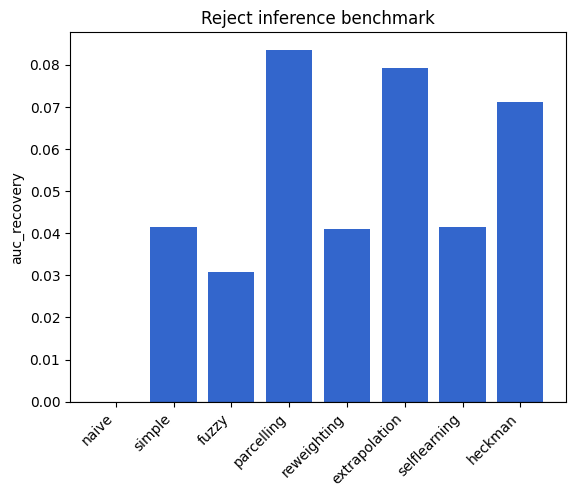

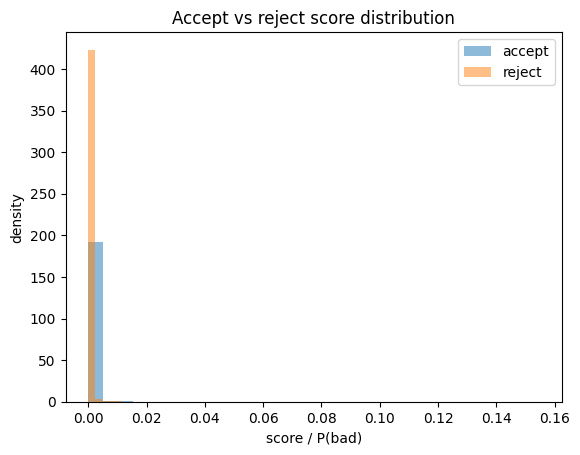

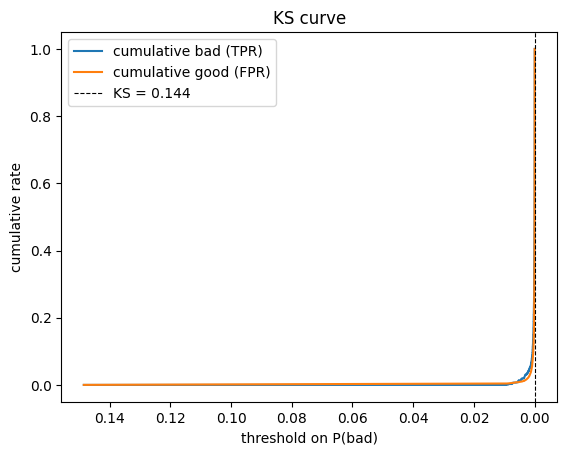

In [6]:
plotting.plot_benchmark(mnar)
plotting.plot_score_distributions(ric.predict_proba(Xa)[:,1], ric.predict_proba(Xr)[:,1])
plotting.plot_ks(yte, ric.predict_proba(Xte)[:,1])
None

## Takeaway / 결론 / まとめ

**[한국어]** 실제 Home Credit 데이터에서, 선택이 결과에 얽힌 MNAR 상황이면 reject inference가 **실질적 이득**을 준다. 다만 MAR·cutoff에선 불필요하고 일부 기법은 해롭다 — 그래서 **언제나 `MaskedRejectBenchmark`로 먼저 확인**하라.

**[English]** On real Home Credit data, when selection is tied to the outcome (MNAR), reject inference gives a **real gain**. But under MAR/cutoff it is unnecessary and some methods hurt — so **always check first with `MaskedRejectBenchmark`**.

**[日本語]** 実際の Home Credit データでは、選択が結果に絡む MNAR で reject inference は**実質的な利得**を与える。ただし MAR・cutoff では不要で一部の手法は有害 — だから**必ず `MaskedRejectBenchmark` で先に確認**すること。